# CNN Image Classifier
Dataset: scikit-learn's digits dataset — 1797 8x8 grayscale images of handwritten digits (0-9). A small CNN is trained to classify them using PyTorch.

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

## Prepare the image dataset
Reshape the flat 64-length vectors back into 8x8 images with a single channel, the format a CNN expects.

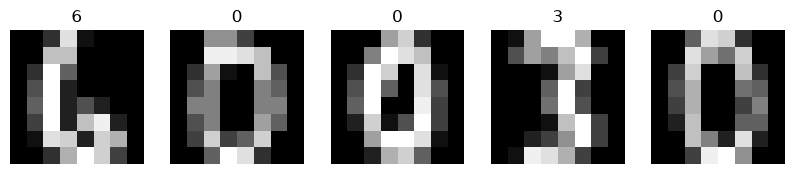

In [9]:
data = load_digits()
images = data.images.astype(np.float32) / 16.0
labels = data.target

images = images.reshape(-1, 1, 8, 8)

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i][0], cmap="gray")
    ax.set_title(str(y_train[i]))
    ax.axis("off")
plt.show()

In [10]:
class ImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ImageDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(ImageDataset(X_test, y_test), batch_size=32, shuffle=False)

## Define the CNN
Two convolutional layers followed by a couple of fully connected layers.

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 2 * 2, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


## Train the CNN

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

epochs = 15
for epoch in range(epochs):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = loss_fn(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1}/{epochs}, loss: {total_loss/len(train_loader):.4f}")

epoch 1/15, loss: 2.2491
epoch 2/15, loss: 1.7387
epoch 3/15, loss: 0.7686
epoch 4/15, loss: 0.4315
epoch 5/15, loss: 0.3085
epoch 6/15, loss: 0.2778
epoch 7/15, loss: 0.2123
epoch 8/15, loss: 0.1785
epoch 9/15, loss: 0.1648
epoch 10/15, loss: 0.1506
epoch 11/15, loss: 0.1300
epoch 12/15, loss: 0.1219
epoch 13/15, loss: 0.1048
epoch 14/15, loss: 0.0970
epoch 15/15, loss: 0.0889


## Accuracy report

In [13]:
correct = 0
total = 0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

accuracy = correct / total
print(f"CNN test accuracy: {accuracy:.4f}")

CNN test accuracy: 0.9639


In [14]:
torch.save(model.state_dict(), "cnn_model.pt")
print("model saved")

model saved
